# Astrometry: residual (head) vs raw offset spread

Per-source spread for all 790 ECDFS tiles with the production (Q1) latent position head.
x = raw classical band$-$VIS offset, y = offset after the head correction; all 10 bands pooled,
**all matched anchors (no dedup, ~555k)**. Points below the y=x line are improved by the head.
(Label-based, i.e. residual is offset to the VIS-centroid convention.)

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError
REPO=find_repo_root()
CACHE=REPO/'models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep.npz'  # non-dedup (all matched anchors)
OUT=REPO/'io/_nb09_outputs/astrom_raw_vs_resid.png'
d=np.load(CACHE, allow_pickle=True)
BANDS=['u','g','r','i','z','y','nisp_Y','nisp_J','nisp_H']
raw=[]; res=[]; snr=[]
for b in BANDS:
    rr=np.asarray(d[f'{b}_raw'])*1000; hr=np.asarray(d[f'{b}_head_resid'])*1000
    raw.append(np.hypot(rr[:,0],rr[:,1])); res.append(np.hypot(hr[:,0],hr[:,1])); snr.append(np.asarray(d[f'{b}_snr']))
raw=np.concatenate(raw); res=np.concatenate(res); snr=np.concatenate(snr)
ok=(raw>0)&(res>0)&np.isfinite(raw)&np.isfinite(res)&np.isfinite(snr)&(snr>0); raw,res,snr=raw[ok],res[ok],snr[ok]
print(f'N anchors: {len(raw):,}')
print(f'raw median {np.median(raw):.1f} mas -> head-resid median {np.median(res):.1f} mas | improved (res<raw): {(res<raw).mean():.0%}')


N anchors: 555,380
raw median 47.9 mas -> head-resid median 13.4 mas | improved (res<raw): 91%


saved io/_nb09_outputs/astrom_raw_vs_resid.png


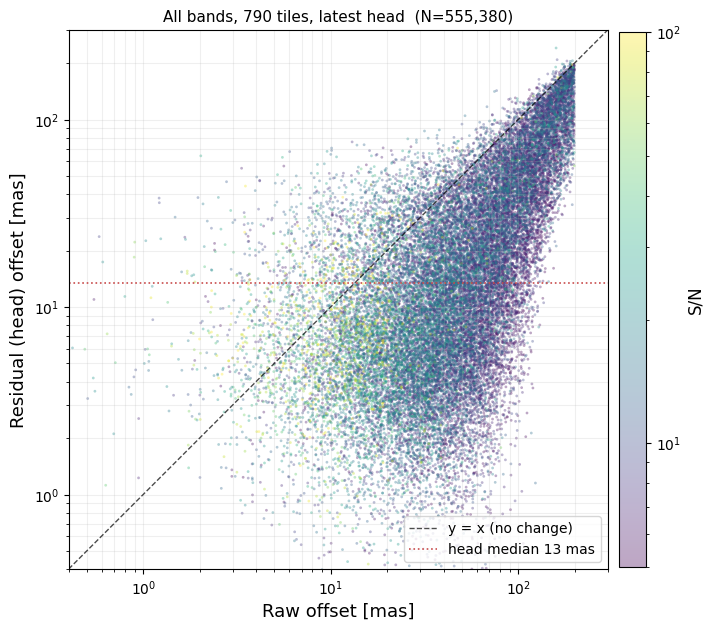

In [2]:
rng=np.random.default_rng(0)
idx=rng.choice(len(raw), min(30000,len(raw)), replace=False)
fig,ax=plt.subplots(figsize=(7.5,7))
from matplotlib.colors import LogNorm
o=np.argsort(snr[idx])   # bright on top
sc=ax.scatter(raw[idx][o],res[idx][o],c=snr[idx][o],s=4,alpha=0.35,edgecolors='none',cmap='viridis',norm=LogNorm(vmin=5,vmax=100),rasterized=True)
cb=fig.colorbar(sc,ax=ax,fraction=0.046,pad=0.02); cb.set_label('S/N',fontsize=12)
lim=[0.4,300]
ax.plot(lim,lim,'k--',lw=1,alpha=0.7,label='y = x (no change)')
ax.axhline(np.median(res),color='#c84b4b',ls=':',lw=1.2,label=f'head median {np.median(res):.0f} mas')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
ax.set_xlabel('Raw offset [mas]',fontsize=13); ax.set_ylabel('Residual (head) offset [mas]',fontsize=13)
ax.grid(True,which='both',alpha=0.2); ax.legend(fontsize=10,loc='lower right')
ax.set_title(f'All bands, 790 tiles, latest head  (N={len(raw):,})',fontsize=11)
OUT.parent.mkdir(parents=True,exist_ok=True)
fig.savefig(OUT,dpi=130,bbox_inches='tight'); print('saved',OUT.relative_to(REPO)); plt.show()


saved io/_nb09_outputs/astrom_hist2d.png


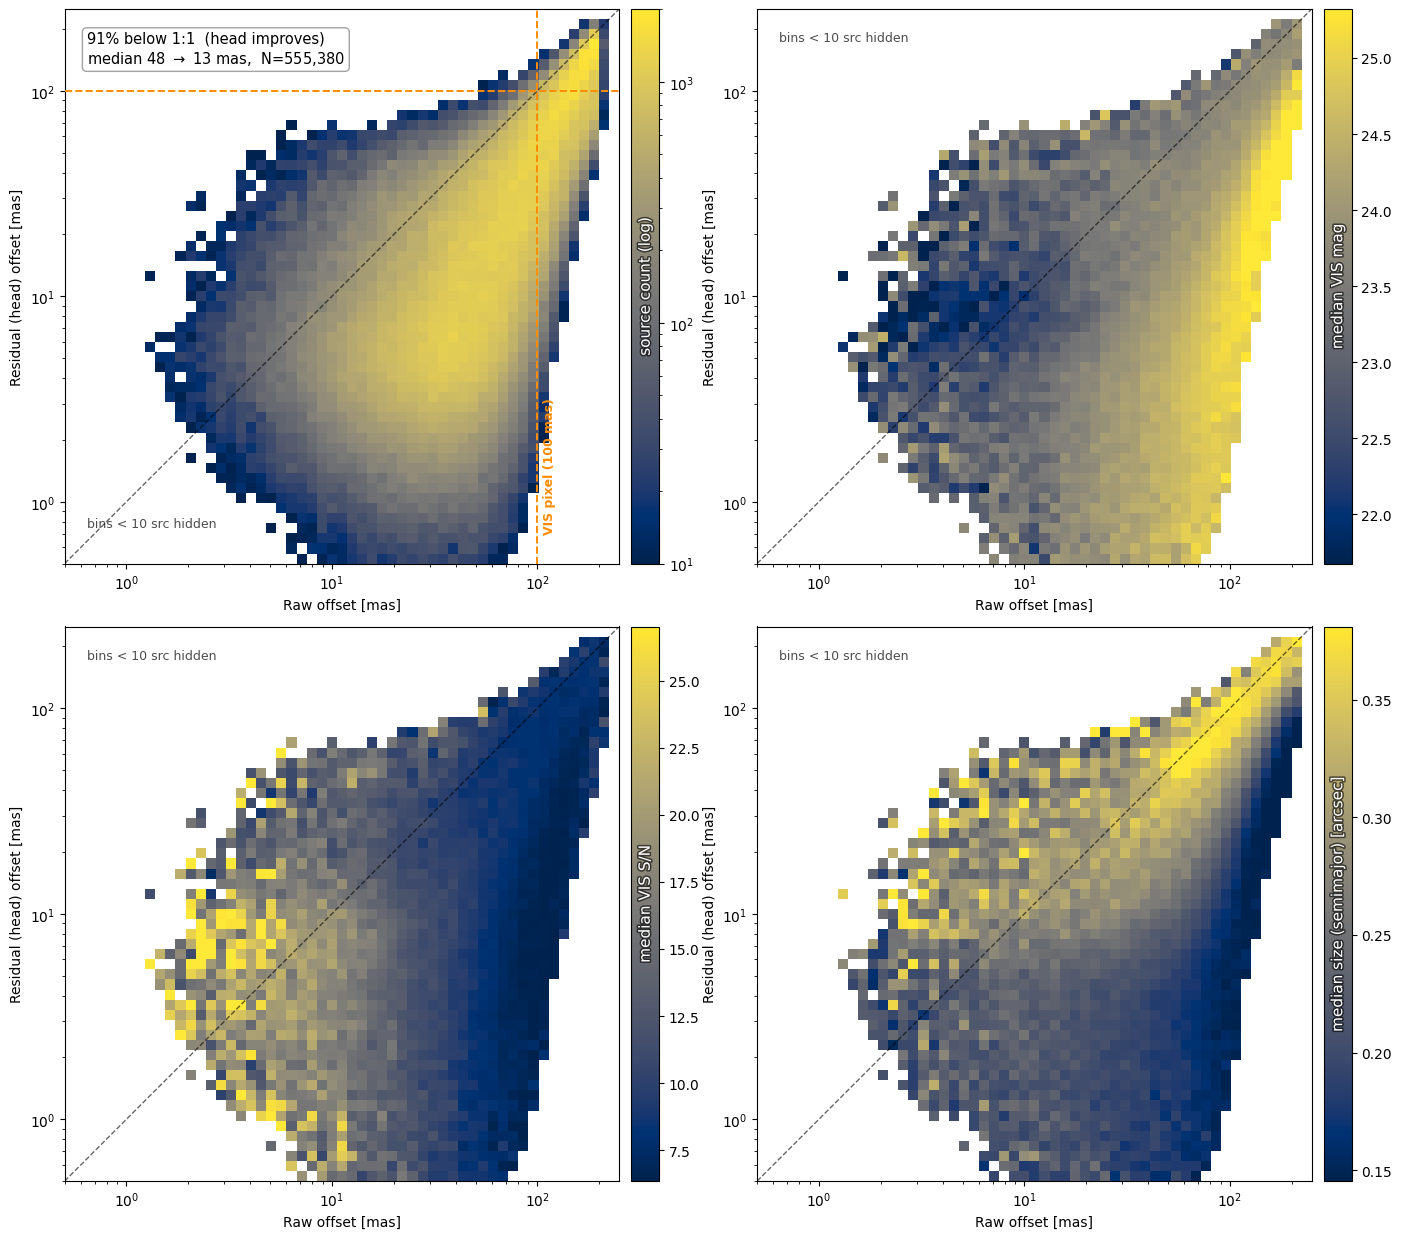

In [3]:
# ---- 4-panel 2D-histogram view: [density, VIS mag, S/N, size] ---------------------
# Square-bin 2D histograms (binned_statistic_2d) on LOG-LOG axes via pcolormesh with
# geometric bin edges. ALL FOUR panels (density included) hard-mask cells with < Nmin
# sources, so the sparse "made worse" tail above 1:1 does not render on any panel -- the
# masking, not the axis scale, is what keeps the ~9% minority from dominating the eye.
# No subpanel titles (the in-bar colorbar label names each panel); single cmap; per-panel
# color range set from data percentiles so the gradient spans the values actually present.
import matplotlib.patheffects as pe
from astropy.io import fits
from scipy.spatial import cKDTree
from scipy.stats import binned_statistic_2d
from matplotlib.colors import LogNorm
BANDS=['u','g','r','i','z','y','nisp_Y','nisp_J','nisp_H']
RAW=[];RES=[];SNR=[];RA=[];DEC=[]
for b in BANDS:
    rr=np.asarray(d[f'{b}_raw'])*1000; hr=np.asarray(d[f'{b}_head_resid'])*1000
    RAW.append(np.hypot(*rr.T));RES.append(np.hypot(*hr.T));SNR.append(np.asarray(d[f'{b}_snr']))
    RA.append(np.asarray(d[f'{b}_ra']));DEC.append(np.asarray(d[f'{b}_dec']))
RAW=np.concatenate(RAW);RES=np.concatenate(RES);SNR=np.concatenate(SNR);RA=np.concatenate(RA);DEC=np.concatenate(DEC)
m0=(RAW>0)&(RES>0)&np.isfinite(RAW)&np.isfinite(RES)&(SNR>0)
RAW,RES,SNR,RA,DEC=RAW[m0],RES[m0],SNR[m0],RA[m0],DEC[m0]
frac_improved=(RES<RAW).mean(); raw_med=np.median(RAW); res_med=np.median(RES)
cosd=np.cos(np.deg2rad(np.median(DEC)))
def match(cra,cdec,vals,rad=0.5):
    t=cKDTree(np.column_stack([cra*cosd,cdec])); dist,idx=t.query(np.column_stack([RA*cosd,DEC]),k=1)
    return np.where(dist*3600<rad, vals[idx], np.nan)
mc=fits.open(REPO/'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_ECDFS_footprint.fits')[1].data
vmag=match(np.asarray(mc['ra'],float),np.asarray(mc['dec'],float),np.asarray(mc['mag_vis'],float))
hs=fits.open(REPO/'data/edf_s_ood/catalogs_compact/mer_q1_ECDFS_Hsize.fits')[1].data
size=match(np.asarray(hs['ra'],float),np.asarray(hs['dec'],float),np.asarray(hs['semimajor_axis'],float)*0.1)

LO,HI=0.5,250; NB=55; Nmin=10          # bins with < Nmin sources are hidden on every panel
VIS_PIX=100.0                          # mas; VIS pixel size = 0.1"/px
CMAP='cividis'                         # single colormap across all panels
edges=np.geomspace(LO,HI,NB+1)
cnt_all=binned_statistic_2d(RAW,RES,None,'count',bins=[edges,edges]).statistic
cnt_all=np.ma.masked_where(cnt_all<Nmin,cnt_all)
def grid_median(C):
    mm=np.isfinite(C)
    med=binned_statistic_2d(RAW[mm],RES[mm],C[mm],'median',bins=[edges,edges]).statistic
    cnt=binned_statistic_2d(RAW[mm],RES[mm],None,'count',bins=[edges,edges]).statistic
    return np.ma.masked_where(cnt<Nmin, med)

def cbar(im,ax,label):
    cb=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.02)
    cb.ax.text(0.5,0.5,label,transform=cb.ax.transAxes,rotation=90,ha='center',va='center',
               fontsize=11,color='white',
               path_effects=[pe.withStroke(linewidth=2.2,foreground='black',alpha=0.6)])
    return cb

fig,axes=plt.subplots(2,2,figsize=(14,12.5)); axes=axes.ravel()
def setup(ax):
    ax.plot([LO,HI],[LO,HI],'k--',lw=1,alpha=0.6,zorder=5)
    ax.set_xscale('log');ax.set_yscale('log')
    ax.set_xlim(LO,HI);ax.set_ylim(LO,HI);ax.set_aspect('equal')
    ax.set_xlabel('Raw offset [mas]');ax.set_ylabel('Residual (head) offset [mas]')

# 1) density (log count) -- masked at the same Nmin as the property panels
im=axes[0].pcolormesh(edges,edges,cnt_all.T,cmap=CMAP,norm=LogNorm(),shading='flat')
setup(axes[0]); cbar(im,axes[0],'source count (log)')
# VIS pixel-size reference (orange cross), density panel only; label vertical, right of the line
axes[0].axvline(VIS_PIX,color='darkorange',ls='--',lw=1.4,zorder=6)
axes[0].axhline(VIS_PIX,color='darkorange',ls='--',lw=1.4,zorder=6)
axes[0].text(VIS_PIX*1.06,LO*1.4,f'VIS pixel ({VIS_PIX:.0f} mas)',color='darkorange',fontsize=9,
             rotation=90,ha='left',va='bottom',fontweight='bold')
axes[0].text(0.04,0.96,f'{frac_improved:.0%} below 1:1  (head improves)\n'
             f'median {raw_med:.0f} $\\rightarrow$ {res_med:.0f} mas,  N={len(RAW):,}',
             transform=axes[0].transAxes,va='top',ha='left',fontsize=10.5,
             bbox=dict(boxstyle='round',fc='white',ec='0.6',alpha=0.9))
axes[0].text(0.04,0.06,f'bins < {Nmin} src hidden',transform=axes[0].transAxes,va='bottom',ha='left',
             fontsize=9,color='0.3',bbox=dict(boxstyle='round',fc='white',ec='none',alpha=0.7))

# 2-4) median-property panels; color range = 2-98th percentile of the binned medians
for ax,(C,lab) in zip(axes[1:],[(vmag,'median VIS mag'),(SNR,'median VIS S/N'),
                                (size,'median size (semimajor) [arcsec]')]):
    med=grid_median(C)
    vmin,vmax=np.nanpercentile(med.compressed(),[2,98])
    im=ax.pcolormesh(edges,edges,med.T,cmap=CMAP,vmin=vmin,vmax=vmax,shading='flat')
    setup(ax); cbar(im,ax,lab)
    ax.text(0.04,0.96,f'bins < {Nmin} src hidden',transform=ax.transAxes,va='top',ha='left',
            fontsize=9,color='0.3',bbox=dict(boxstyle='round',fc='white',ec='none',alpha=0.7))
plt.tight_layout()
HEXOUT=REPO/'io/_nb09_outputs/astrom_hist2d.png'
fig.savefig(HEXOUT,dpi=130,bbox_inches='tight'); print('saved',HEXOUT.relative_to(REPO)); plt.show()


saved io/_nb09_outputs/astrom_hist2d_compact.png


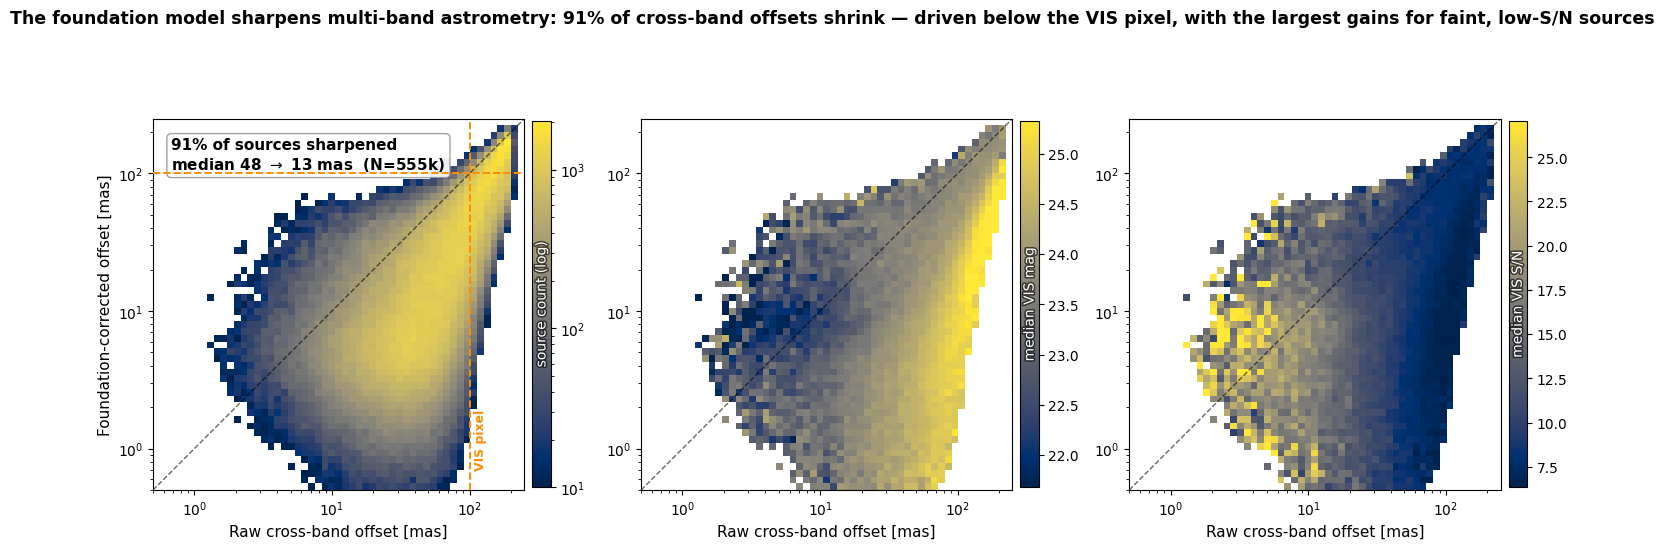

In [4]:
# ---- compact proposal figure (1x3): foundation model improves astrometry ----------
# Reuses arrays/helpers from the cell above (edges, cnt_all, grid_median, vmag, SNR,
# frac_improved, raw_med, res_med, CMAP, LO/HI, VIS_PIX). Framing: "head" -> "foundation".
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
XLAB='Raw cross-band offset [mas]'
YLAB='Foundation-corrected offset [mas]'
figc,axc=plt.subplots(1,3,figsize=(15,5.3))
def setupc(ax):
    ax.plot([LO,HI],[LO,HI],'k--',lw=1,alpha=0.6,zorder=5)
    ax.set_xscale('log');ax.set_yscale('log')
    ax.set_xlim(LO,HI);ax.set_ylim(LO,HI);ax.set_aspect('equal')
    ax.set_xlabel(XLAB,fontsize=11)
def cbarc(im,ax,label):
    cb=figc.colorbar(im,ax=ax,fraction=0.046,pad=0.02)
    cb.ax.text(0.5,0.5,label,transform=cb.ax.transAxes,rotation=90,ha='center',va='center',
               fontsize=10,color='white',path_effects=[pe.withStroke(linewidth=2.2,foreground='black',alpha=0.6)])

# density + VIS pixel reference
im=axc[0].pcolormesh(edges,edges,cnt_all.T,cmap=CMAP,norm=LogNorm(),shading='flat')
setupc(axc[0]); axc[0].set_ylabel(YLAB,fontsize=11); cbarc(im,axc[0],'source count (log)')
axc[0].axvline(VIS_PIX,color='darkorange',ls='--',lw=1.4,zorder=6)
axc[0].axhline(VIS_PIX,color='darkorange',ls='--',lw=1.4,zorder=6)
axc[0].text(VIS_PIX*1.08,LO*1.4,'VIS pixel',color='darkorange',fontsize=9,rotation=90,
            ha='left',va='bottom',fontweight='bold')
axc[0].text(0.05,0.95,f'{frac_improved:.0%} of sources sharpened\n'
            f'median {raw_med:.0f} $\\rightarrow$ {res_med:.0f} mas  (N={len(RAW)/1e3:.0f}k)',
            transform=axc[0].transAxes,va='top',ha='left',
            fontsize=11,fontweight='bold',bbox=dict(boxstyle='round',fc='white',ec='0.6',alpha=0.92))

# median VIS mag + VIS S/N (first three panels total)
for ax,(C,lab) in zip(axc[1:],[(vmag,'median VIS mag'),(SNR,'median VIS S/N')]):
    med=grid_median(C); vmin,vmax=np.nanpercentile(med.compressed(),[2,98])
    im=ax.pcolormesh(edges,edges,med.T,cmap=CMAP,vmin=vmin,vmax=vmax,shading='flat')
    setupc(ax); cbarc(im,ax,lab)

figc.suptitle('The foundation model sharpens multi-band astrometry: 91% of cross-band offsets shrink '
              '— driven below the VIS pixel, with the largest gains for faint, low-S/N sources',
              fontsize=12.5,fontweight='bold',y=1.03)
plt.tight_layout()
OUTC=REPO/'io/_nb09_outputs/astrom_hist2d_compact.png'
figc.savefig(OUTC,dpi=140,bbox_inches='tight'); print('saved',OUTC.relative_to(REPO)); plt.show()
